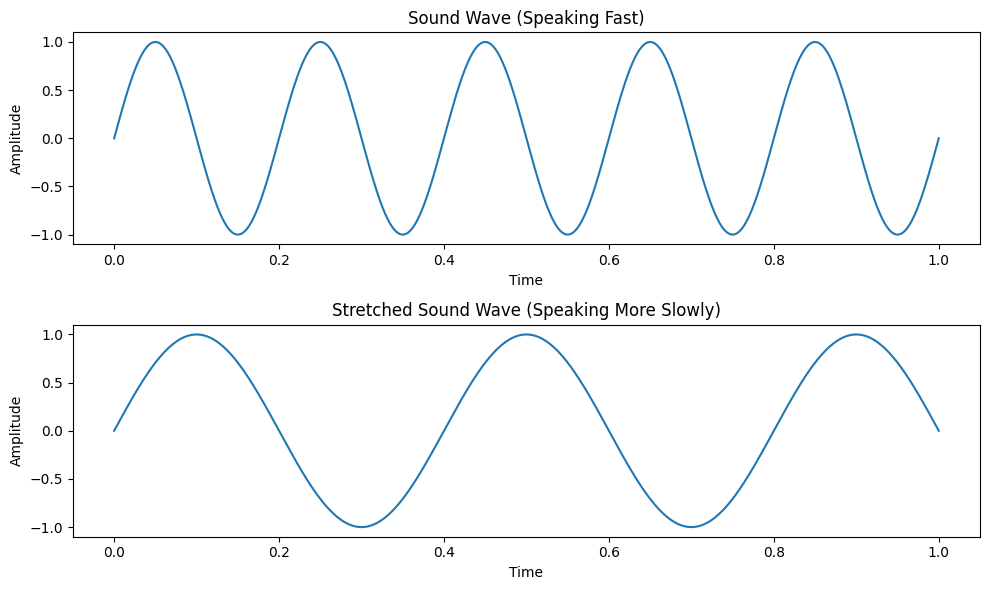

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generating a simple sound wave as an example
t = np.linspace(0, 1, 1000)
sound_wave_fast = np.sin(2 * np.pi * 5 * t)  # 5 Hz tone

# Stretching the sound wave to simulate speaking more slowly
# We'll simulate this by reducing the frequency
sound_wave_slow = np.sin(2 * np.pi * 2.5 * t)  # 2.5 Hz tone, half the original frequency

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the fast speaking sound wave
axs[0].plot(t, sound_wave_fast)
axs[0].set_title('Sound Wave (Speaking Fast)')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Amplitude')

# Plotting the stretched sound wave (speaking more slowly)
axs[1].plot(t, sound_wave_slow)
axs[1].set_title('Stretched Sound Wave (Speaking More Slowly)')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from dtaidistance import dtw
from scipy.stats import pearsonr
import pandas as pd

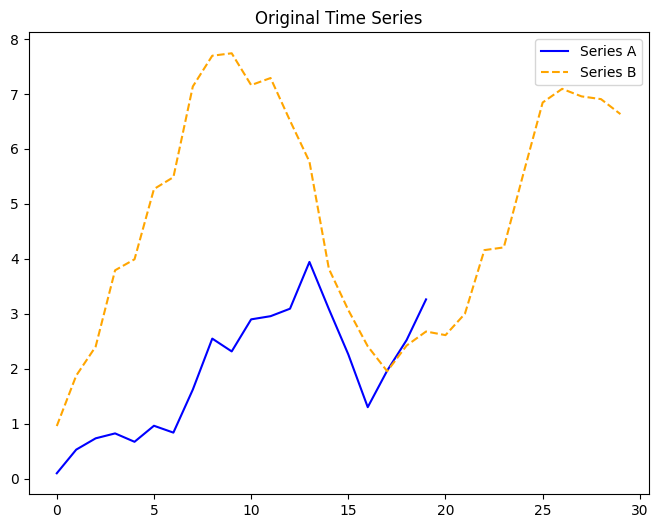

In [5]:
np.random.seed(0)
time_series_a = np.cumsum(np.random.rand(20) * 2 - 1)
time_series_b = np.cumsum(np.random.rand(30) * 2 - 1 + np.sin(np.linspace(0, 3 * np.pi, 30)))

# Create a figure and a single subplot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plotting the time series
ax1.plot(time_series_a, label='Series A', color='blue')
ax1.plot(time_series_b, label='Series B', linestyle='--', color='orange')

# Setting the title and legend
ax1.set_title('Original Time Series')
ax1.legend()

plt.show()

In [6]:
distance, paths = dtw.warping_paths(time_series_a, time_series_b, use_c=False)
best_path = dtw.best_path(paths)
similarity_score = distance / len(best_path)

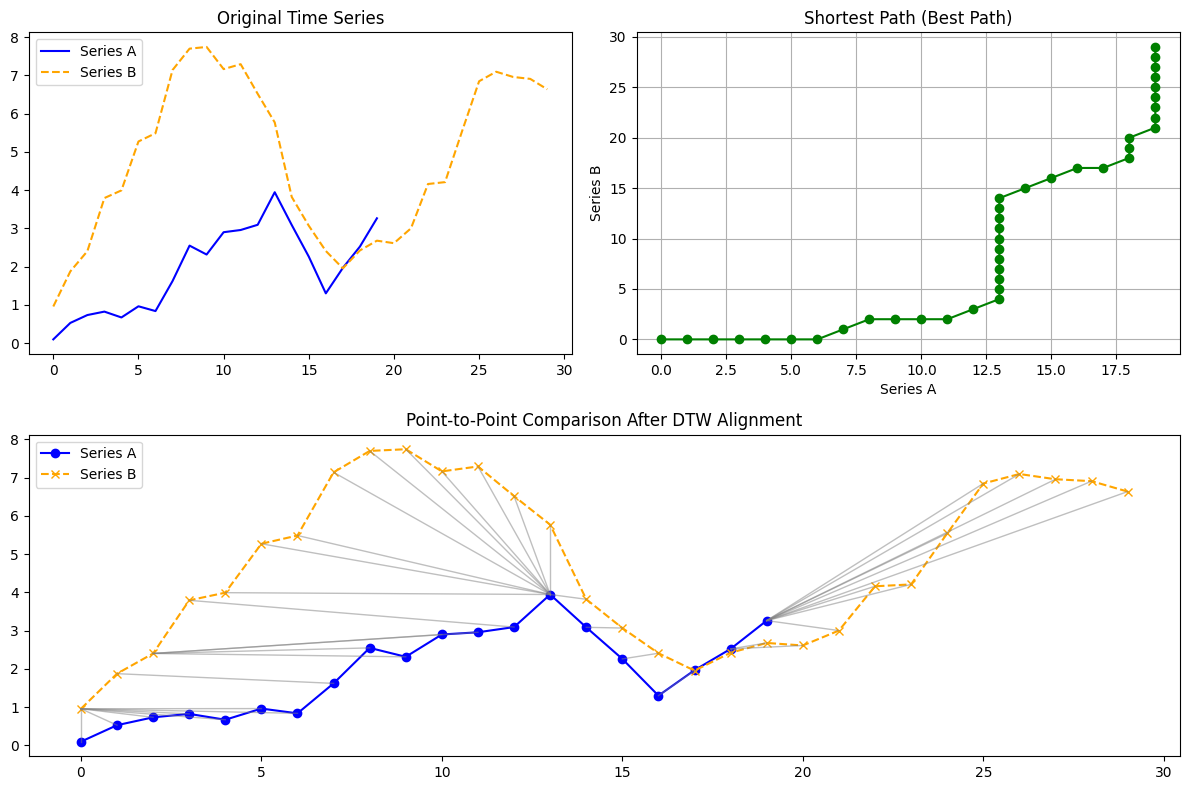

In [7]:
plt.figure(figsize=(12, 8))

# Original Time Series Plot
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(time_series_a, label='Series A', color='blue')
ax1.plot(time_series_b, label='Series B', linestyle='--',color='orange')
ax1.set_title('Original Time Series')
ax1.legend()

# Shortest Path Plot (Cost Matrix with the path)
# In this example, only the path is plotted, not the entire cost matrix.

ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(np.array(best_path)[:, 0], np.array(best_path)[:, 1], 'green', marker='o', linestyle='-')
ax2.set_title('Shortest Path (Best Path)')
ax2.set_xlabel('Series A')
ax2.set_ylabel('Series B')
ax2.grid(True)

# Point-to-Point Comparison Plot
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.plot(time_series_a, label='Series A', color='blue', marker='o')
ax3.plot(time_series_b, label='Series B', color='orange', marker='x', linestyle='--')
for a, b in best_path:
    ax3.plot([a, b], [time_series_a[a], time_series_b[b]], color='grey', linestyle='-', linewidth=1, alpha = 0.5)
ax3.set_title('Point-to-Point Comparison After DTW Alignment')
ax3.legend()

plt.tight_layout()
plt.show()

In [8]:
results_df = pd.DataFrame({
    'Metric': ['DTW Similarity Score'],
    'Value': [similarity_score]
})

results_df['Description'] = [
    "Lower scores indicate greater similarity between the time series."
]

results_df

,Metric,Value,Description
0,DTW Similarity Score,0.306018,Lower scores indicate greater similarity betwe...


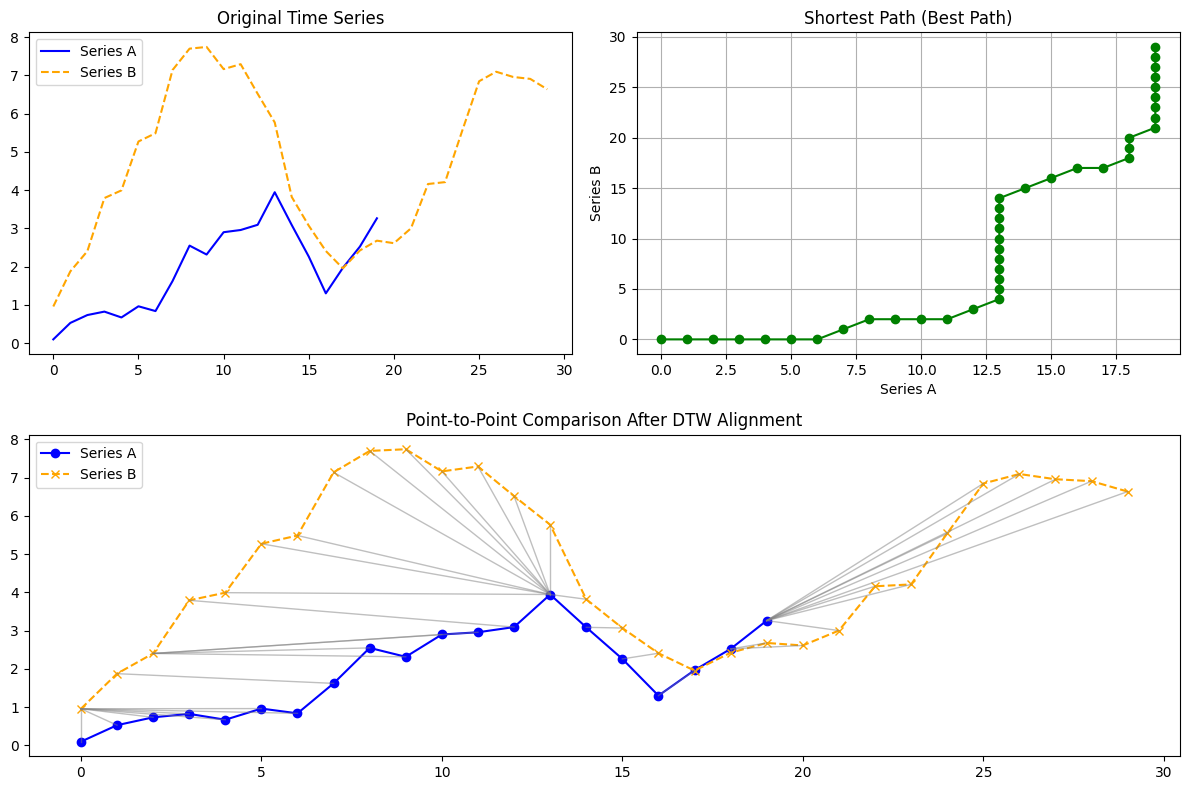

,Metric,Value,Description
0,DTW Similarity Score,0.306018,Lower scores indicate greater similarity betwe...


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from dtaidistance import dtw
from scipy.stats import pearsonr
import pandas as pd

# Generate dummy data for the time series

np.random.seed(0)
time_series_a = np.cumsum(np.random.rand(20) * 2 - 1)
time_series_b = np.cumsum(np.random.rand(30) * 2 - 1 + np.sin(np.linspace(0, 3 * np.pi, 30)))

# Calculate DTW distance and obtain the warping paths (no need for the C library)
distance, paths = dtw.warping_paths(time_series_a, time_series_b, use_c=False)
best_path = dtw.best_path(paths)

similarity_score = distance / len(best_path)

plt.figure(figsize=(12, 8))

# Original Time Series Plot
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(time_series_a, label='Series A', color='blue')
ax1.plot(time_series_b, label='Series B', linestyle='--',color='orange')
ax1.set_title('Original Time Series')
ax1.legend()

# Shortest Path Plot (Cost Matrix with the path)
# In this example, only the path is plotted, not the entire cost matrix.

ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(np.array(best_path)[:, 0], np.array(best_path)[:, 1], 'green', marker='o', linestyle='-')
ax2.set_title('Shortest Path (Best Path)')
ax2.set_xlabel('Series A')
ax2.set_ylabel('Series B')
ax2.grid(True)


# Point-to-Point Comparison Plot
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.plot(time_series_a, label='Series A', color='blue', marker='o')
ax3.plot(time_series_b, label='Series B', color='orange', marker='x', linestyle='--')
for a, b in best_path:
    ax3.plot([a, b], [time_series_a[a], time_series_b[b]], color='grey', linestyle='-', linewidth=1, alpha = 0.5)
ax3.set_title('Point-to-Point Comparison After DTW Alignment')
ax3.legend()

plt.tight_layout()
plt.show()

# Create a DataFrame to display the similarity score and correlation coefficient
results_df = pd.DataFrame({
    'Metric': ['DTW Similarity Score'],
    'Value': [similarity_score]
})

# Add descriptions for the results
results_df['Description'] = [
    "Lower scores indicate greater similarity between the time series."
]

results_df

DYNAMIC TIME WARPING RESULTS
Series A length: 50
Series B length: 60
DTW Distance: 12.1241
Warping Path Length: 66
Average point-wise distance: 0.1837

For comparison:
Euclidean Distance (truncated to 50 points): 2.3880


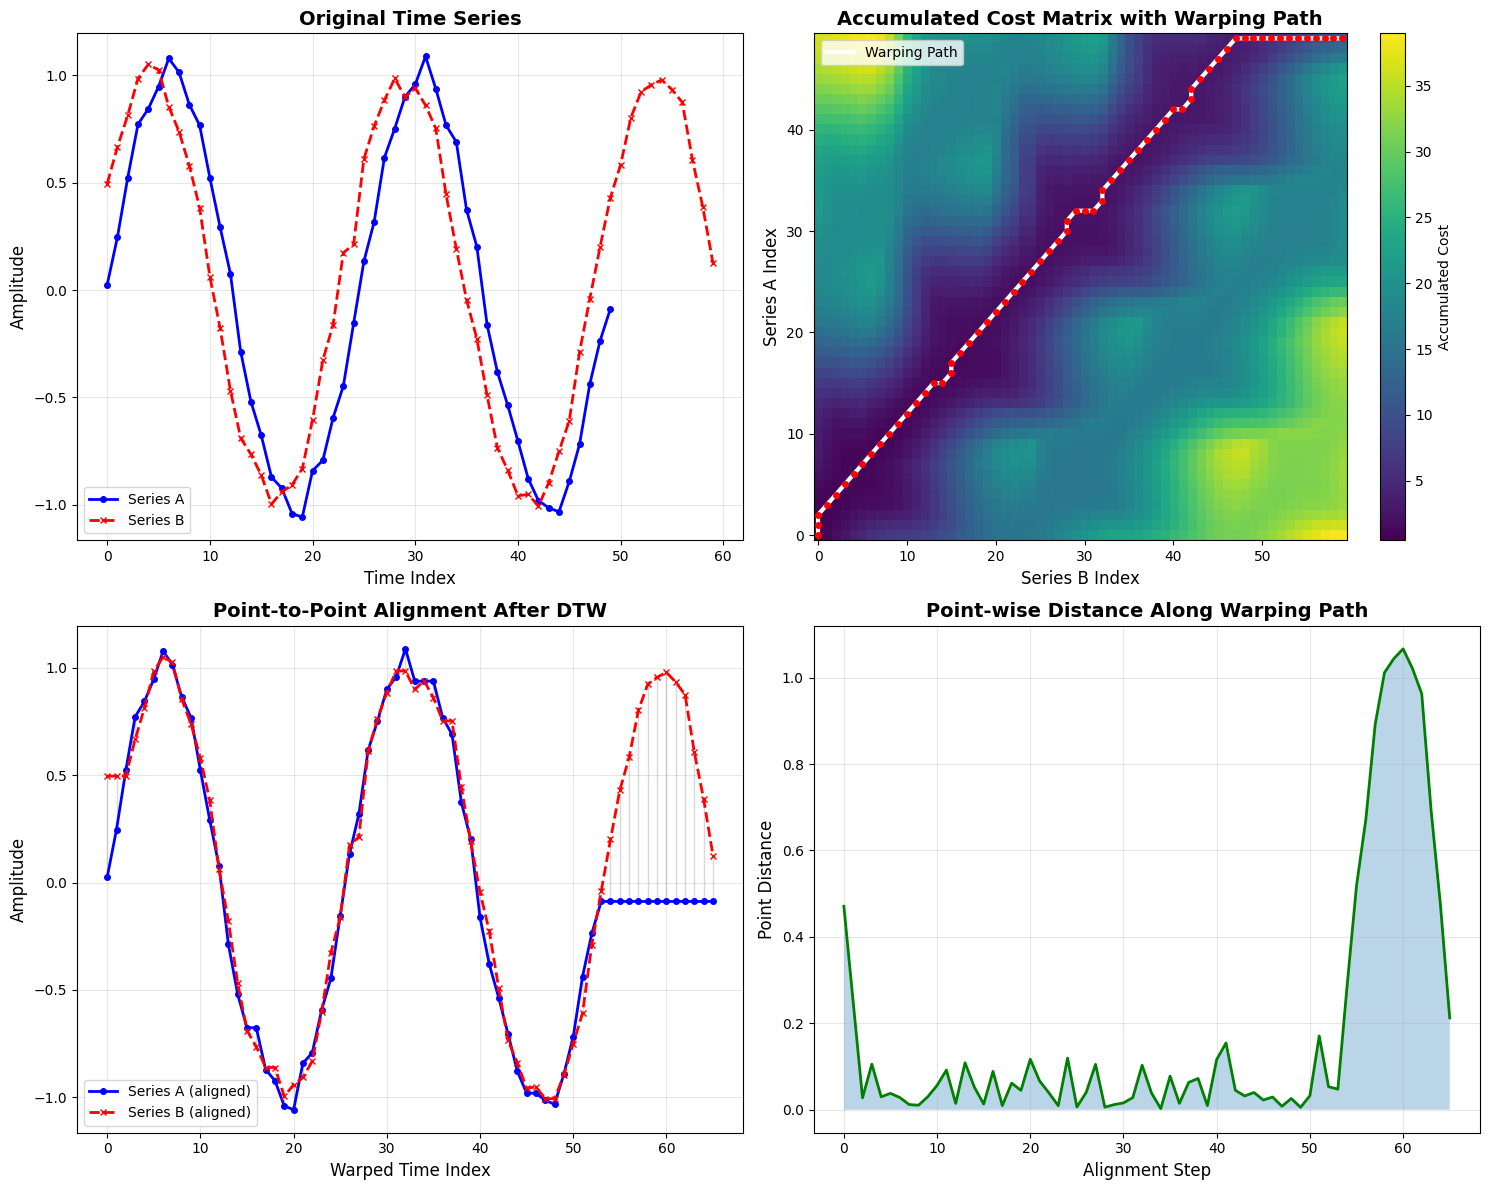


First 10 alignment points (Series A index -> Series B index):
------------------------------------------------------------
Step 1: A[0] = 0.025 -> B[0] = 0.496 | Dist: 0.471
Step 2: A[1] = 0.247 -> B[0] = 0.496 | Dist: 0.249
Step 3: A[2] = 0.523 -> B[0] = 0.496 | Dist: 0.027
Step 4: A[3] = 0.772 -> B[1] = 0.666 | Dist: 0.105
Step 5: A[4] = 0.843 -> B[2] = 0.814 | Dist: 0.030
Step 6: A[5] = 0.947 -> B[3] = 0.985 | Dist: 0.038
Step 7: A[6] = 1.078 -> B[4] = 1.050 | Dist: 0.028
Step 8: A[7] = 1.013 -> B[5] = 1.025 | Dist: 0.012
Step 9: A[8] = 0.863 -> B[6] = 0.853 | Dist: 0.010
Step 10: A[9] = 0.767 -> B[7] = 0.737 | Dist: 0.030


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

def dtw(series_a, series_b):
    """
    Compute Dynamic Time Warping distance and optimal warping path.
    
    Parameters:
    -----------
    series_a : array-like
        First time series
    series_b : array-like
        Second time series
    
    Returns:
    --------
    distance : float
        DTW distance between the two series
    cost_matrix : ndarray
        Accumulated cost matrix
    path : list of tuples
        Optimal warping path as (i, j) index pairs
    """
    n, m = len(series_a), len(series_b)
    
    # Initialize cost matrix with infinity
    cost_matrix = np.full((n + 1, m + 1), np.inf)
    cost_matrix[0, 0] = 0
    
    # Fill the cost matrix using dynamic programming
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Calculate local cost (Euclidean distance)
            cost = abs(series_a[i - 1] - series_b[j - 1])
            
            # Take minimum of three possible paths
            cost_matrix[i, j] = cost + min(
                cost_matrix[i - 1, j],      # insertion
                cost_matrix[i, j - 1],      # deletion
                cost_matrix[i - 1, j - 1]   # match
            )
    
    # Backtrack to find optimal warping path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        
        # Find which direction we came from
        min_cost = min(
            cost_matrix[i - 1, j],
            cost_matrix[i, j - 1],
            cost_matrix[i - 1, j - 1]
        )
        
        if cost_matrix[i - 1, j - 1] == min_cost:
            i, j = i - 1, j - 1
        elif cost_matrix[i - 1, j] == min_cost:
            i = i - 1
        else:
            j = j - 1
    
    path.reverse()
    
    return cost_matrix[n, m], cost_matrix[1:, 1:], path


def visualize_dtw(series_a, series_b, cost_matrix, path):
    """
    Visualize the DTW alignment with multiple plots.
    
    Parameters:
    -----------
    series_a : array-like
        First time series
    series_b : array-like
        Second time series
    cost_matrix : ndarray
        Accumulated cost matrix from DTW
    path : list of tuples
        Optimal warping path
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Original time series
    ax1 = axes[0, 0]
    ax1.plot(series_a, 'b-o', label='Series A', linewidth=2, markersize=4)
    ax1.plot(series_b, 'r--x', label='Series B', linewidth=2, markersize=4)
    ax1.set_xlabel('Time Index', fontsize=12)
    ax1.set_ylabel('Amplitude', fontsize=12)
    ax1.set_title('Original Time Series', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Cost matrix with warping path
    ax2 = axes[0, 1]
    im = ax2.imshow(cost_matrix, cmap='viridis', origin='lower', aspect='auto')
    
    # Plot warping path
    path_array = np.array(path)
    ax2.plot(path_array[:, 1], path_array[:, 0], 'w-', linewidth=3, label='Warping Path')
    ax2.plot(path_array[:, 1], path_array[:, 0], 'r.', markersize=8)
    
    ax2.set_xlabel('Series B Index', fontsize=12)
    ax2.set_ylabel('Series A Index', fontsize=12)
    ax2.set_title('Accumulated Cost Matrix with Warping Path', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax2, label='Accumulated Cost')
    ax2.legend(fontsize=10)
    
    # Plot 3: Aligned time series using warping path
    ax3 = axes[1, 0]
    for i, (idx_a, idx_b) in enumerate(path):
        ax3.plot([i, i], [series_a[idx_a], series_b[idx_b]], 
                'gray', alpha=0.3, linewidth=1)
    
    warped_time = np.arange(len(path))
    aligned_a = [series_a[idx_a] for idx_a, _ in path]
    aligned_b = [series_b[idx_b] for _, idx_b in path]
    
    ax3.plot(warped_time, aligned_a, 'b-o', label='Series A (aligned)', 
            linewidth=2, markersize=4)
    ax3.plot(warped_time, aligned_b, 'r--x', label='Series B (aligned)', 
            linewidth=2, markersize=4)
    ax3.set_xlabel('Warped Time Index', fontsize=12)
    ax3.set_ylabel('Amplitude', fontsize=12)
    ax3.set_title('Point-to-Point Alignment After DTW', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Distance visualization
    ax4 = axes[1, 1]
    distances = [abs(series_a[idx_a] - series_b[idx_b]) for idx_a, idx_b in path]
    ax4.plot(distances, 'g-', linewidth=2)
    ax4.fill_between(range(len(distances)), distances, alpha=0.3)
    ax4.set_xlabel('Alignment Step', fontsize=12)
    ax4.set_ylabel('Point Distance', fontsize=12)
    ax4.set_title('Point-wise Distance Along Warping Path', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Generate two sine waves with different frequencies and phases
np.random.seed(42)

# Series A: Standard sine wave
t_a = np.linspace(0, 4 * np.pi, 50)
series_a = np.sin(t_a)

# Series B: Sine wave with different frequency (compressed/stretched)
t_b = np.linspace(0, 4 * np.pi, 60)
series_b = np.sin(1.2 * t_b + 0.5)  # Different frequency and phase shift

# Add small noise
series_a += np.random.normal(0, 0.05, len(series_a))
series_b += np.random.normal(0, 0.05, len(series_b))

# Compute DTW
dtw_distance, cost_matrix, warping_path = dtw(series_a, series_b)

# Print results
print("=" * 60)
print("DYNAMIC TIME WARPING RESULTS")
print("=" * 60)
print(f"Series A length: {len(series_a)}")
print(f"Series B length: {len(series_b)}")
print(f"DTW Distance: {dtw_distance:.4f}")
print(f"Warping Path Length: {len(warping_path)}")
print(f"Average point-wise distance: {dtw_distance / len(warping_path):.4f}")
print("=" * 60)

# For comparison: Calculate standard Euclidean distance
# (only possible if series have same length, so we'll truncate)
min_len = min(len(series_a), len(series_b))
euclidean_dist = np.sqrt(np.sum((series_a[:min_len] - series_b[:min_len])**2))
print(f"\nFor comparison:")
print(f"Euclidean Distance (truncated to {min_len} points): {euclidean_dist:.4f}")
print("=" * 60)

# Visualize
visualize_dtw(series_a, series_b, cost_matrix, warping_path)

# Additional: Show first few alignment points
print("\nFirst 10 alignment points (Series A index -> Series B index):")
print("-" * 60)
for i, (idx_a, idx_b) in enumerate(warping_path[:10]):
    print(f"Step {i+1}: A[{idx_a}] = {series_a[idx_a]:.3f} -> B[{idx_b}] = {series_b[idx_b]:.3f} | Dist: {abs(series_a[idx_a] - series_b[idx_b]):.3f}")